In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skdim
import os
# load .mat data
import scipy.io
from scipy.linalg import pinvh

%load_ext autoreload
%autoreload 2

# load data
# get the DATA_PATH from the environment variable
data_path = os.getenv('DATA_PATH')
folder = data_path
X_filename = 'trainingAll4D_Eb_sim_standardized.mat'
Y_filename = 'trainingAll4D_Em_sim_masked_standardized.mat'
H_filename = 'H_gridded.mat'
mask_filename = 'training_mask.mat'
model_bound_filename = 'training_mask_domain_continuous.mat'
# also the mean and std of Eb for reverse standardization
Eb_mean_filename = 'trainingAll_Eb_sim_mean.mat'
Eb_std_filename = 'trainingAll_Eb_sim_std.mat'

X_data = scipy.io.loadmat(folder + X_filename)
Y_data = scipy.io.loadmat(folder + Y_filename)
mask_data = scipy.io.loadmat(folder + mask_filename)
H_data = scipy.io.loadmat(folder + H_filename)
model_bound_data = scipy.io.loadmat(folder + model_bound_filename)

Shape of Eb_standardized: (256, 256, 1, 742)
Shape of Em_standardized: (256, 256, 1, 742)
Shape of mask: (256, 256)


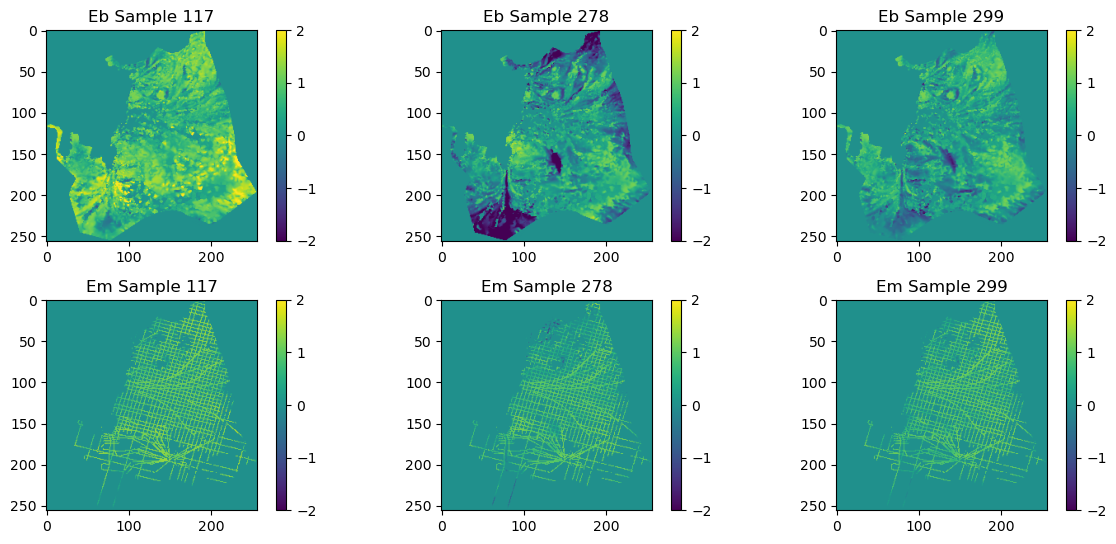

In [2]:
Eb_standardized = X_data['Eb_standardized']
Em_standardized = Y_data['Em_standardized_masked']
mask = mask_data['mask']
print('Shape of Eb_standardized:', Eb_standardized.shape)
print('Shape of Em_standardized:', Em_standardized.shape)
print('Shape of mask:', mask.shape)

# plot three random samples (Eb and Em) for visual
num_samples = Eb_standardized.shape[3]
random_indices = np.random.choice(num_samples, size=3, replace=False)
# figure size
plt.figure(figsize=(12, 8))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(Eb_standardized[:, :, :, idx], cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Eb Sample {idx}')
    plt.colorbar()
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 4)
    plt.imshow(Em_standardized[:, :, :, idx], cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Em Sample {idx}')
    plt.colorbar()
plt.tight_layout()
plt.show()

### Investigate the relationship between ensemble size and intrinsic dimension

shape of data_reshaped: (742, 65536)


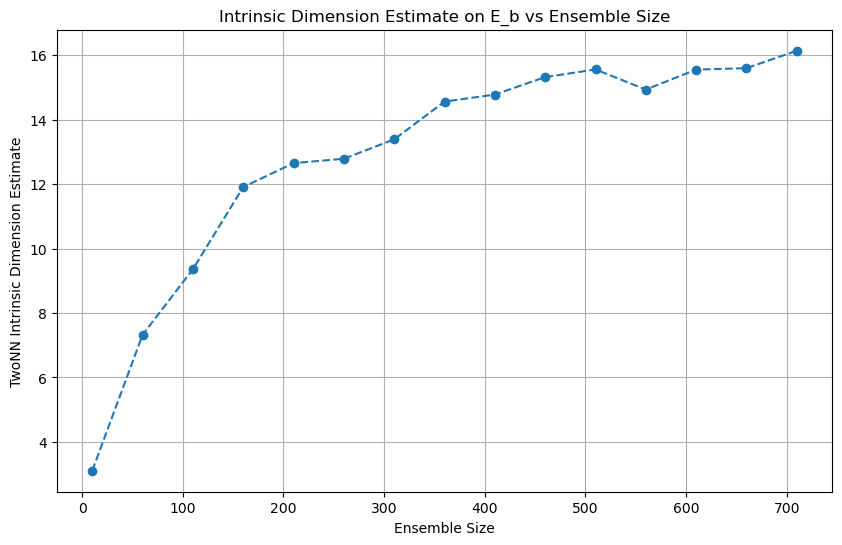

In [3]:
# randomly shuffle data_reshaped
# apply the same analysis to Eb_standardized data, which now has dimension (nx, ny, 1, n_samples) where nx*ny is the full spatial dimension for each sample
nx, ny, _, n_samples = Eb_standardized.shape
data_reshaped = Eb_standardized.reshape((nx * ny, n_samples)).T
print('shape of data_reshaped:', data_reshaped.shape)

np.random.seed(0)
shuffled_indices = np.random.permutation(data_reshaped.shape[0])
data_shuffled = data_reshaped[shuffled_indices]

ensemble_size = range(10, n_samples + 1, 50)
townn_estimates = []

for size in ensemble_size:
    subset = data_shuffled[:size,:]
    twonn = skdim.id.TwoNN().fit(subset)
    townn_estimates.append(twonn.dimension_)

# Plot intrinsic dimension estimates vs ensemble size
plt.figure(figsize=(10, 6))
plt.plot(ensemble_size, townn_estimates, marker='o', linestyle='--')
plt.xlabel('Ensemble Size')
plt.ylabel('TwoNN Intrinsic Dimension Estimate')
plt.title('Intrinsic Dimension Estimate on E_b vs Ensemble Size')
plt.grid()
plt.show()

### Compare PCA to the intrinsic dimension estimates

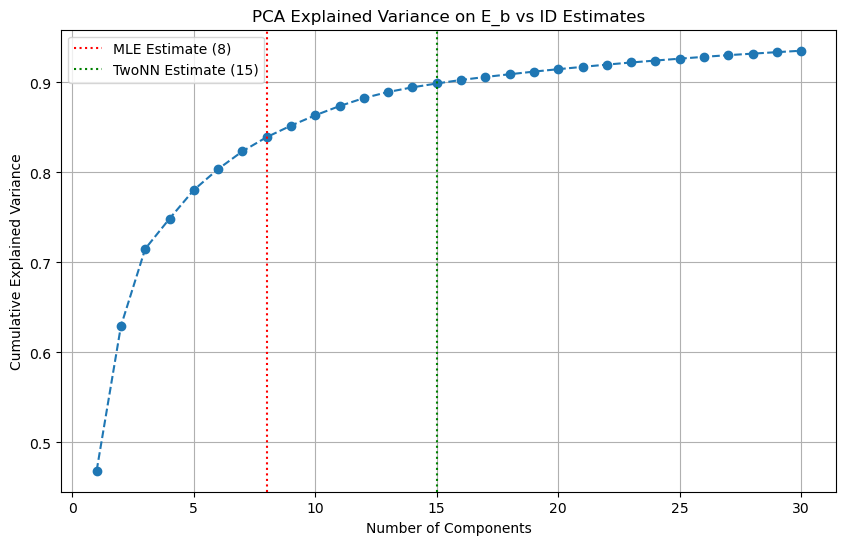

Variance at 8 dims: 0.839
Variance at 15 dims: 0.899


In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Fit PCA
pca = PCA(n_components=30) # Look at top 30
pca.fit(data_reshaped)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), cumulative_variance, marker='o', linestyle='--')
plt.axvline(x=8, color='r', linestyle=':', label='MLE Estimate (8)')
plt.axvline(x=15, color='g', linestyle=':', label='TwoNN Estimate (15)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance on E_b vs ID Estimates')
plt.legend()
plt.grid(True)
plt.show()

# Check values
print(f"Variance at 8 dims: {cumulative_variance[7]:.3f}")
print(f"Variance at 15 dims: {cumulative_variance[14]:.3f}")


shape of X_reshaped: (742, 65536)
shape of Y_reshaped: (742, 65536)
Explained Variance (X): 0.926
Explained Variance (Y): 0.992


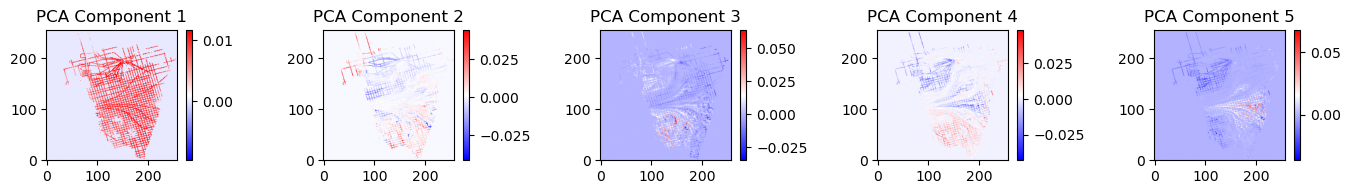

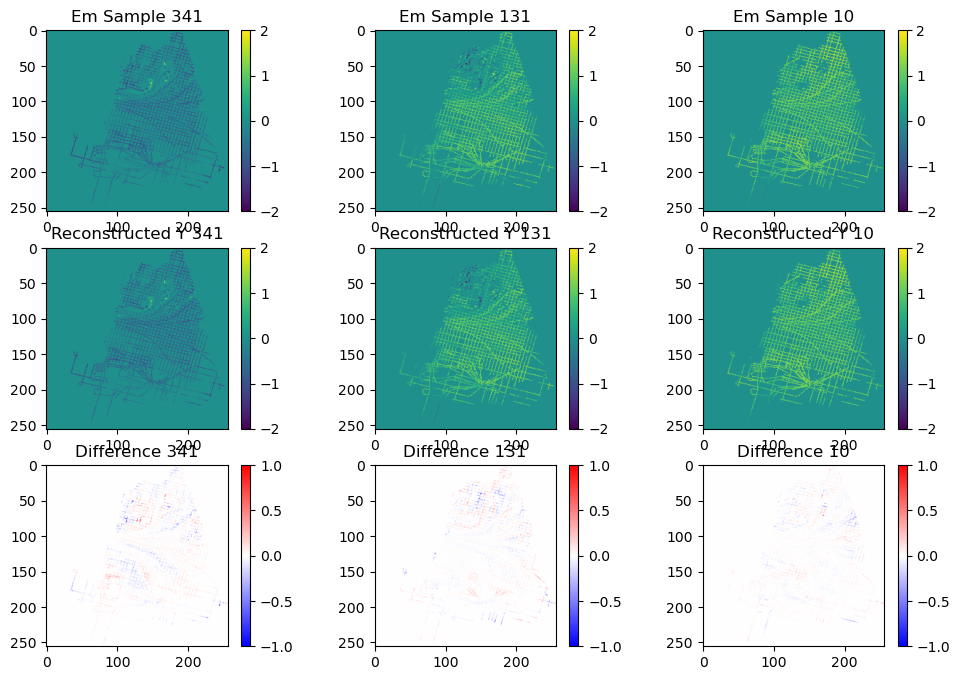

In [5]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np


# apply the same analysis to Eb_standardized data, which now has dimension (nx, ny, 1, n_samples) where nx*ny is the full spatial dimension for each sample
nx, ny, _, n_samples = Eb_standardized.shape
X_reshaped = Eb_standardized.reshape((nx * ny, n_samples)).T
# Y_reshaped = Eb_standardized_masked.reshape((nx * ny, n_samples)).T
Y_reshaped = Em_standardized.reshape((nx * ny, n_samples)).T
print('shape of X_reshaped:', X_reshaped.shape)
print('shape of Y_reshaped:', Y_reshaped.shape)

# 1. PCA Step: Compress 65k -> 18 dimensions
# We choose 18 to capture slightly more than the TwoNN estimate (buffer for curvature)
pca_X = PCA(n_components=25) 
X_reduced = pca_X.fit_transform(X_reshaped)

pca_Y = PCA(n_components=20)
Y_reduced = pca_Y.fit_transform(Y_reshaped)

print(f"Explained Variance (X): {np.sum(pca_X.explained_variance_ratio_):.3f}")
print(f"Explained Variance (Y): {np.sum(pca_Y.explained_variance_ratio_):.3f}")


# visualize the first 5 PCA components for Y
plt.figure(figsize=(14, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    component_img = pca_Y.components_[i].reshape((nx, ny))
    plt.imshow(component_img, cmap='bwr')
    plt.title(f'PCA Component {i+1}')
    plt.colorbar()
    plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# check how well reconstructed Y_reduced using the PCA components learned from Eb_standardized_masked 
# can capture the variance in Em_standardized
reconstructed_Y = pca_Y.inverse_transform(Y_reduced)  # shape (n_samples, 65536)

# visualize three random samples
random_indices = np.random.choice(n_samples, size=3, replace=False)
plt.figure(figsize=(12, 8))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(Em_standardized[:, :, :, idx], cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Em Sample {idx}')
    plt.colorbar()
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 4)
    plt.imshow(reconstructed_Y[idx].reshape(nx, ny), cmap='viridis', vmin = -2, vmax = 2)
    plt.title(f'Reconstructed Y {idx}')
    plt.colorbar()
# difference
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 7)
    plt.imshow(Em_standardized[:, :, :, idx].squeeze() - reconstructed_Y[idx].reshape(nx, ny), cmap='bwr', vmin = -1, vmax = 1)
    plt.title(f'Difference {idx}')
    plt.colorbar()

# Using Gaussian Mixture model on the latent space

In [6]:
from gmr.utils import check_random_state
from gmr import MVN, GMM, plot_error_ellipses
from gmr.mvn import regression_coefficients
from gmr.gmm import _safe_probability_density

from scipy.sparse.linalg import eigsh, LinearOperator
from scipy.spatial import cKDTree
import time

from src.amortization import form_obs_cov_col, build_spatial_covariance_operator, sample_from_spatial_cov, pushforward, propagate_uncertainty
from src.amortization import compute_conditional_expected_val, compute_conditional_std_val_latent

#### Loading and training

In [7]:
ndim_X = X_reduced.shape[1]
ndim_Y = Y_reduced.shape[1]

random_state = check_random_state(42)
# mvn = GMM(n_components = 10, random_state=random_state)
mvn = MVN(random_state=random_state)

# combine the reduced dimension of X and Y along the column dimension
XY_reduced = np.hstack((Y_reduced, X_reduced))

# shuffle and split a subset for training (90%) and testing (10%)
n_samples = XY_reduced.shape[0]
indices = np.arange(n_samples)
random_state.shuffle(indices)
split_point = int(0.9 * n_samples)
train_indices = indices[:split_point]
test_indices = indices[split_point:]
XY_train = XY_reduced[train_indices]
XY_test = XY_reduced[test_indices]

print('shape of XY_train:', XY_train.shape)
print('shape of XY_test:', XY_test.shape)

ndim_X = X_reduced.shape[1]
ndim_Y = Y_reduced.shape[1]

random_state = check_random_state(42)
gmm = GMM(n_components=20, random_state=random_state)

# combine the reduced dimension of X and Y along the column dimension
# notice here that Y is before X, which means the first few dimensions are Y.T
# we need to be consistent later on when supplying the condition index during our inference stage.
XY_reduced = np.hstack((Y_reduced, X_reduced))

# shuffle and split a subset for training (90%) and testing (10%)
n_samples = XY_reduced.shape[0]
indices = np.arange(n_samples)
random_state.shuffle(indices)
split_point = int(0.9 * n_samples)
train_indices = indices[:split_point]
test_indices = indices[split_point:]
XY_train = XY_reduced[train_indices]
XY_test = XY_reduced[test_indices]

print('shape of XY_train:', XY_train.shape)
print('shape of XY_test:', XY_test.shape)

# create GMM, P(Y,X)
# time the training time
start_time = time.time()
gmm.from_samples(XY_train)
end_time = time.time()
training_time = end_time - start_time
print(f"GMM training time: {training_time:.2f} seconds")




shape of XY_train: (667, 45)
shape of XY_test: (75, 45)
shape of XY_train: (667, 45)
shape of XY_test: (75, 45)
GMM training time: 1.38 seconds


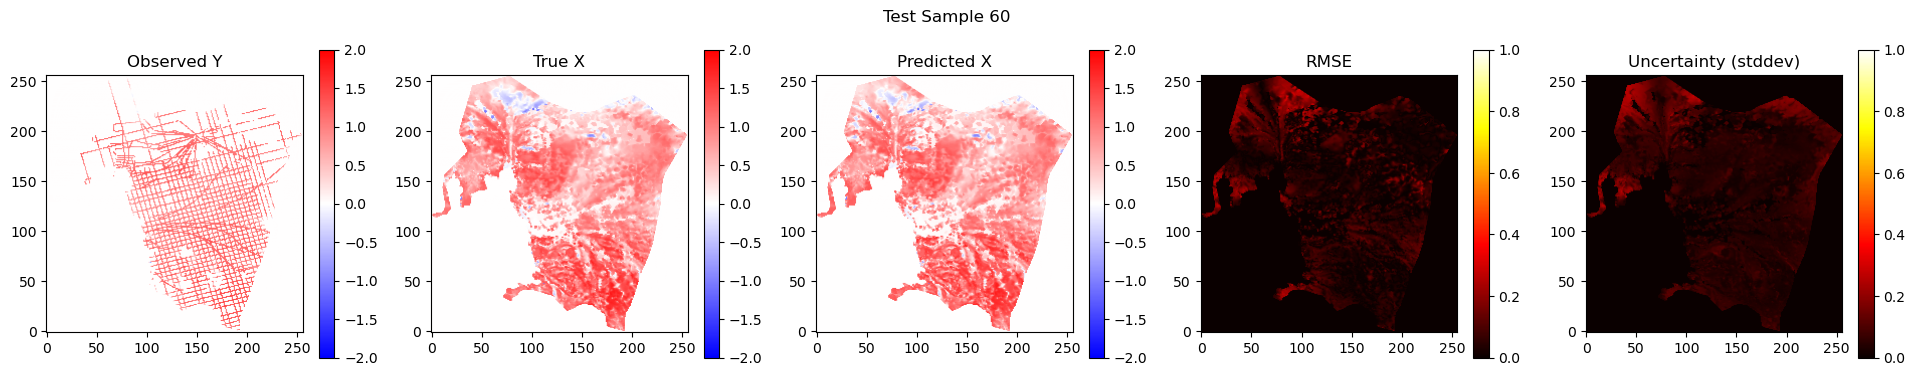

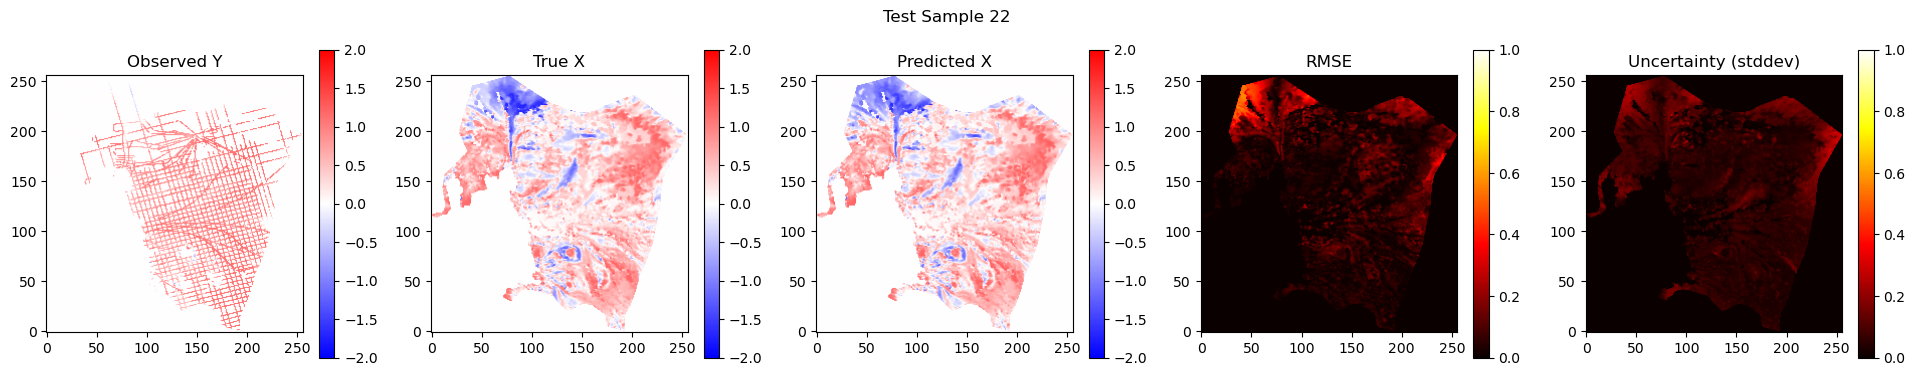

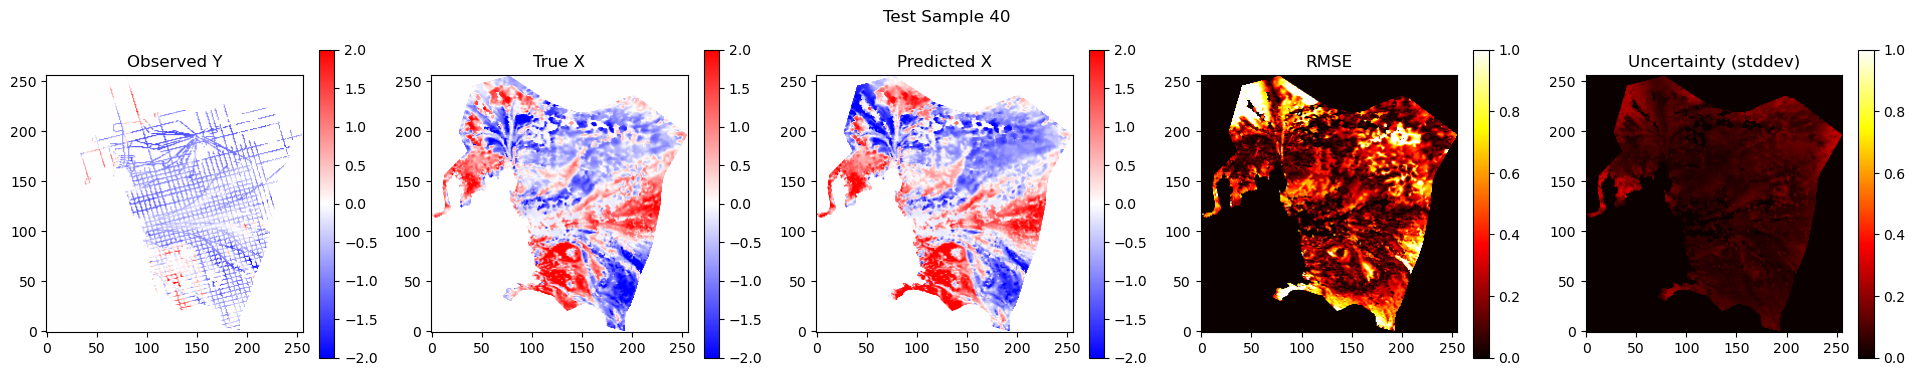

In [8]:

# test first three samples from the test set and visualize the prediction
n_test_samples = len(test_indices)
n_test_samples_plot = 3 
rand_idx = np.random.choice(range(n_test_samples), size=n_test_samples_plot, replace=False)
for i in rand_idx:
    y_test = XY_test[i, :ndim_Y]  # Y part
    x_test = XY_test[i, ndim_Y:]  # X part

    # Predict X given Y
    condition_index = np.arange(ndim_Y)
    x_pred_gmm = gmm.condition(condition_index, y_test)

    # sample from this conditional distribution to get uncertainty
    n_uq_sample = 400
    x_uq_samples = x_pred_gmm.sample(n_uq_sample)
    x_uq_samples_ori = np.zeros((256*256, n_uq_sample))
    # Inverse transform to original space
    # then the uq samples
    for j, sample in enumerate(x_uq_samples):
        x_uq_samples_ori[:,j] = pca_X.inverse_transform(sample)

    # compute the mean from the ensemble
    x_pred_mean = np.mean(x_uq_samples_ori, axis=1)
    x_pred_img = x_pred_mean.reshape(256, 256)
    
    # compute std along each dimension of the uq samples
    x_uq_std = np.std(x_uq_samples_ori, axis=1)
    x_uq_std = x_uq_std.reshape(256, 256)

    # Reshape X for visualization
    x_test_original = pca_X.inverse_transform(x_test.reshape(1, -1))
    x_test_img = x_test_original.reshape(256, 256)

    # observed Y
    obs_Y = pca_Y.inverse_transform(y_test)
    obs_Y = obs_Y.reshape(256, 256)
    # Plotting: five columns: observed Y, True X, predicted X, error (RMSE), uncertainty (stddev)
    plt.figure(figsize=(24, 4))
    plt.subplot(1, 5, 1)
    plt.imshow(obs_Y, cmap='bwr', vmin=-2, vmax=2)
    plt.title('Observed Y')
    plt.colorbar()
    # invert y axis
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 2)
    plt.imshow(x_test_img, cmap='bwr', vmin=-2, vmax=2)
    plt.title('True X')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 3)
    plt.imshow(x_pred_img, cmap='bwr', vmin=-2, vmax=2)
    plt.title('Predicted X')
    plt.colorbar()
    plt.gca().invert_yaxis()
    
    plt.subplot(1, 5, 4)
    rmse_img = np.sqrt((x_test_img - x_pred_img) ** 2)
    plt.imshow(rmse_img, cmap='hot', vmin = 0, vmax = 1)
    plt.title('RMSE')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.subplot(1, 5, 5)
    plt.imshow(x_uq_std, cmap='hot', vmin = 0, vmax = 1)
    plt.title('Uncertainty (stddev)')
    plt.colorbar()
    plt.gca().invert_yaxis()

    plt.suptitle(f'Test Sample {i+1}')
    # save the figure, dpi = 300
    plt.savefig(f'test_sample_{i+1}_prediction.png', dpi=300)
    plt.show()

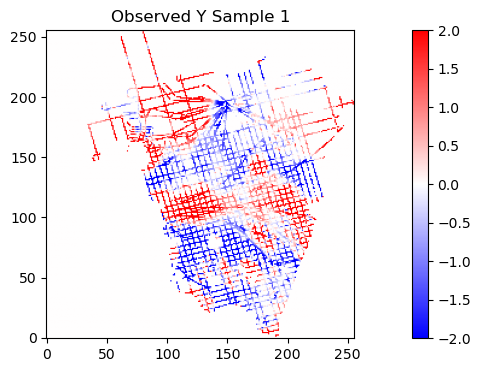

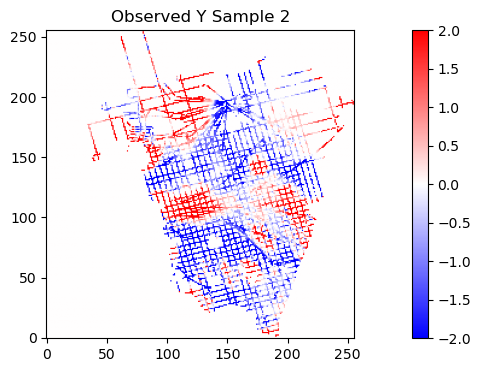

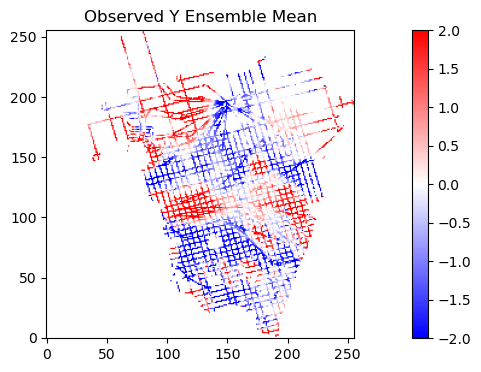

In [9]:
# load observed Y data
Y_obs_filename = "Em_gridded_masked_standardized_ensemble.mat"
Y_obs_data = scipy.io.loadmat(folder + Y_obs_filename)

Y_obs_data = Y_obs_data['Em_obs_standard_ensemble_struct']
Y_obs_data = Y_obs_data['data'][0][0]

# plot the first three samples of Y obs
for i in range(2):
    Y_obs_sample = Y_obs_data[:, :, i]
    plt.figure(figsize=(15, 4))
    plt.imshow(Y_obs_sample, cmap='bwr', vmin=-2, vmax=2)
    plt.title(f'Observed Y Sample {i+1}')
    plt.colorbar()
    plt.gca().invert_yaxis()
    plt.show()

# compute the ensemble mean
Y_obs_mean = np.mean(Y_obs_data, axis=2)
plt.figure(figsize=(15, 4))
plt.imshow(Y_obs_mean, cmap='bwr', vmin=-2, vmax=2)
plt.title('Observed Y Ensemble Mean')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

In [10]:
# sampling from the covariance explictly
# construct a covariance matrix for the observation to account for epstemic uncertainty
# we need the mask array and ice thickness array
H = H_data['H_struct']['H'][0][0].flatten()
X = H_data['H_struct']['X'][0][0].flatten()
Y = H_data['H_struct']['Y'][0][0].flatten()

# build the linear operator for contructing covariance matrix sampling
Sigma_op, _ = build_spatial_covariance_operator(H, X, Y, mask)

# use PCA-reconstructed Y_obs_mean for consistency with the analytical propagation later
mu_obs_latent = pca_Y.transform(Y_obs_mean.reshape(1, -1))
mu_obs_reconstructed = pca_Y.inverse_transform(mu_obs_latent).reshape(256, 256)

# # 2. Use it for MC Sampling Validation
# samples, samples_zeromean, _ = sample_from_spatial_cov(H, X, Y, mask, mean = mu_obs_reconstructed, sigma_op=Sigma_op, num_samples=300, 
#                                         rank=100, cutoff_factor=5.0, tol=1e-3, verbose=True)

# # visualize 5 random samples from 'samples'
# # need to reshape each sample back to 256x256
# n_samples_to_plot = 5
# sample_indices = np.random.choice(samples.shape[1], n_samples_to_plot, replace=False)
# plt.figure(figsize=(20, 4))
# for i, idx in enumerate(sample_indices):    
#     sample_img = samples_zeromean[:, idx].reshape(256, 256)
#     plt.subplot(1, n_samples_to_plot, i+1)
#     plt.imshow(sample_img, cmap='hot', vmin=-3, vmax=3)
#     plt.title(f'Sample {idx}')
#     plt.colorbar()
#     plt.gca().invert_yaxis()
# plt.suptitle('Samples from Spatial Covariance (mean removed)')
# plt.show()

# plt.figure(figsize=(20, 4))
# for i, idx in enumerate(sample_indices):    
#     sample_img = samples[:, idx].reshape(256, 256)
#     plt.subplot(1, n_samples_to_plot, i+1)
#     plt.imshow(sample_img, cmap='hot', vmin=-3, vmax=3)
#     plt.title(f'Sample {idx}')
#     plt.colorbar()
#     plt.gca().invert_yaxis()
# plt.suptitle('Samples from Spatial Covariance (mean added)')
# plt.show()

# # propagate to get the expected values and std through sampling
# Em_obs_reduced = np.transpose(pca_Y.transform(samples.T)) 

# Eb_prop_mean_reduced = compute_conditional_expected_val(gmm, np.arange(ndim_Y), Em_obs_reduced)
# Eb_prop_mean = pca_X.inverse_transform(Eb_prop_mean_reduced.squeeze()).reshape(256, 256)

# Eb_prop_std = compute_conditional_std_val_latent(gmm, np.arange(ndim_Y), Em_obs_reduced,
#                                                         Eb_prop_mean, pca_X)
# # plot
# plt.figure(figsize=(12, 5))
# plt.subplot(1, 2, 1)
# plt.imshow(Eb_prop_mean, cmap='bwr', vmin=-5, vmax=5)
# plt.title('GMR Propagated Mean (PCA-reconstructed Y_obs_mean)')
# plt.colorbar()
# plt.gca().invert_yaxis()

# plt.subplot(1, 2, 2)
# plt.imshow(Eb_prop_std.reshape(256,256), cmap='hot', vmin=0, vmax=10)
# plt.title('GMR Propagated Std (PCA-reconstructed Y_obs_std)')
# plt.colorbar()
# plt.gca().invert_yaxis()

# plt.show()

Building Operator | Size: n = 65,536
Valid points: 9,885 | Length scale: 200.0 km
Building spatial index (KD-tree)...
Precomputing neighbor lists...
Avg neighbors: 9885 | Sparsity: 15.08%


### Analytical propagation of uncertainty

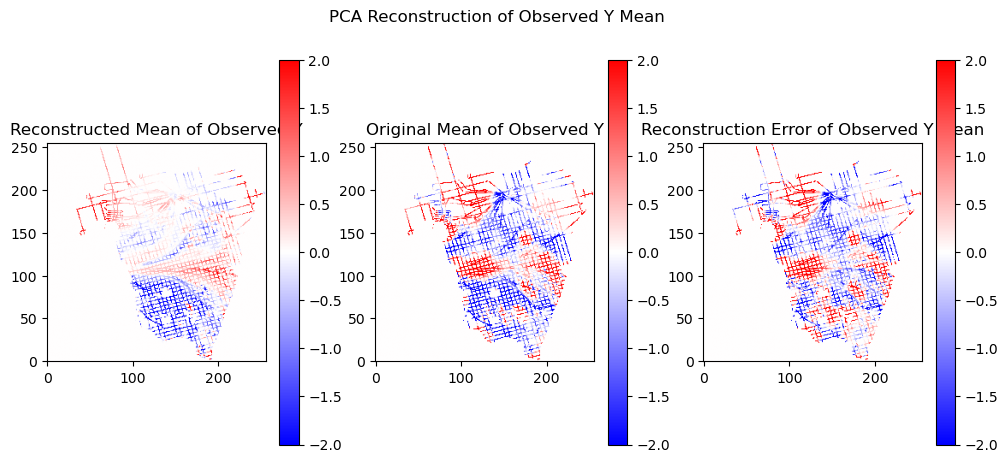

In [11]:
# getting the mean and covariance into the latent space
VT = pca_Y.components_ 
n_components = VT.shape[0]
Sigma_VT = np.zeros_like(VT.T) # (N, k)

for k in range(n_components):
    # Apply operator to each principal component
    Sigma_VT[:, k] = Sigma_op.matvec(VT[k, :])

cov_obs_latent = VT @ Sigma_VT
mu_obs_latent  = pca_Y.transform(Y_obs_mean.reshape(1,-1))

mu_obs_recons = pca_Y.inverse_transform(mu_obs_latent)
mu_obs_recons_img = mu_obs_recons.reshape(256, 256)

mu_obs_recons_err =  Y_obs_mean.flatten()-mu_obs_recons
mu_obs_recons_err_img = mu_obs_recons_err.reshape(256, 256)
plt.figure(figsize=(12, 5))
plt.subplot(1,3,1)
plt.imshow(mu_obs_recons_img, cmap='bwr', vmin=-2, vmax=2)
plt.title('Reconstructed Mean of Observed Y')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1,3,2)
plt.imshow(Y_obs_mean, cmap='bwr', vmin=-2, vmax=2)
plt.title('Original Mean of Observed Y')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1,3,3)
plt.imshow(mu_obs_recons_err_img, cmap='bwr', vmin=-2, vmax=2)
plt.title('Reconstruction Error of Observed Y Mean')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('PCA Reconstruction of Observed Y Mean')
plt.show()



In [12]:
# export the reconstruction error with its coordinate
import pandas as pd
# create a dataframe with columns 'X', 'Y', 'Reconstruction_Error'
df_recon_error = pd.DataFrame({
    'X': X,
    'Y': Y,
    'Reconstruction_Error': mu_obs_recons_err.T.flatten()
})
# save
df_recon_error.to_csv('pca_reconstruction_error.csv', index=False)

conditioned indices are:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


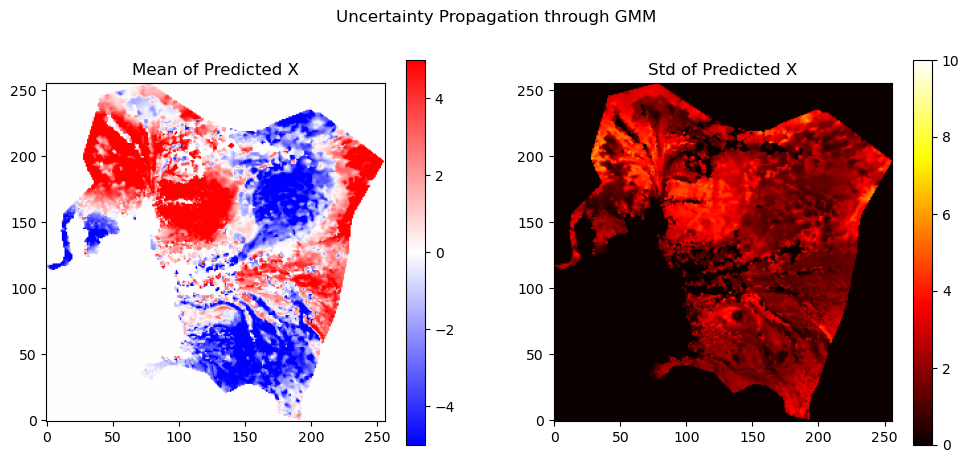

In [13]:
# propagate the observational uncertainty through the GMM to get the uncertainty in X
gmm_propagated = propagate_uncertainty(mu_obs_latent.T, cov_obs_latent, gmm, np.arange(ndim_Y), XY_train[:,:ndim_Y])

# sample from gmm_propagated to get the distribution of X
n_samples = 300
X_samples = gmm_propagated.sample(n_samples)
X_samples_ori = np.zeros((256*256, n_samples))
for i, sample in enumerate(X_samples):
    X_samples_ori[:,i] = pca_X.inverse_transform(sample)

# visualize the mean and variance
X_samples_mean = np.mean(X_samples_ori, axis=1).reshape(256, 256)
X_samples_std = np.std(X_samples_ori, axis=1).reshape(256, 256)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(X_samples_mean, cmap='bwr', vmin=-5, vmax=5)
plt.title('Mean of Predicted X')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(X_samples_std, cmap='hot', vmin=0, vmax=10)
plt.title('Std of Predicted X')
plt.colorbar()
plt.gca().invert_yaxis()
plt.suptitle('Uncertainty Propagation through GMM')
plt.show()

# clear x_samples_ori to save memory
del X_samples_ori

# Finding Maximum A Posteriori in the latent space

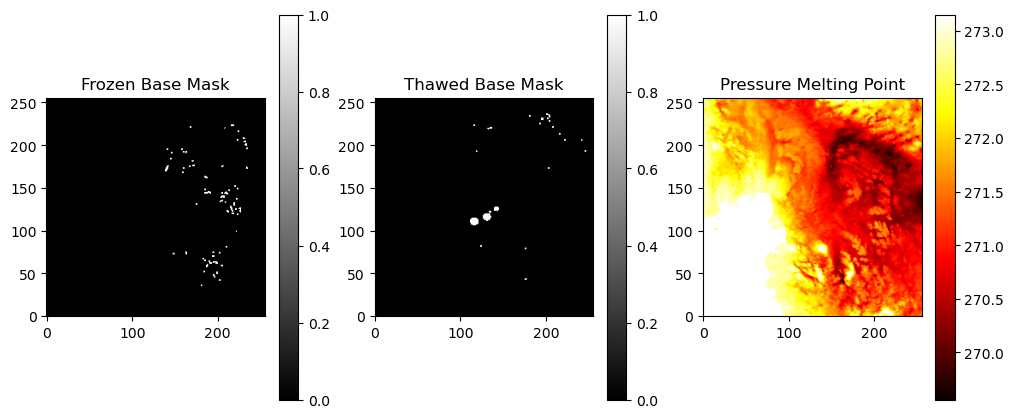

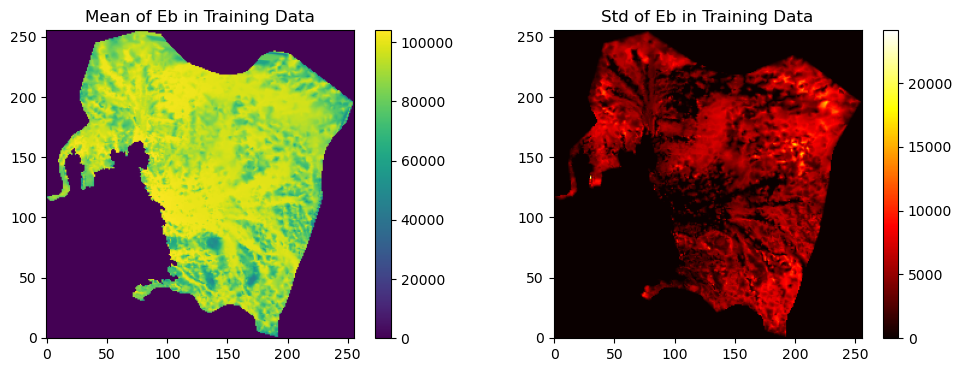

In [14]:
from src.ice import compute_pmp
from src.amortization import to_log_probability_density
from src.optimization import log_posterior_gradient, log_posterior

# load the thawed base and frozen base data
frozen_base_filename = folder + "../../basal-frozen-mask/frozen_mask.mat"
thawed_base_filename = folder + "../../basal-water-mask/water_mask.mat"
frozen_mask = scipy.io.loadmat(frozen_base_filename)['frozen_mask']
thawed_mask = scipy.io.loadmat(thawed_base_filename)['water_mask']
frozen_mask_data = frozen_mask['data'][0][0]
thawed_mask_data = thawed_mask['data'][0][0]

Eb_mean_data = scipy.io.loadmat(folder + Eb_mean_filename)
Eb_std_data = scipy.io.loadmat(folder + Eb_std_filename)
# replace nan by 0
Eb_mean_data = np.nan_to_num(Eb_mean_data['Eb_mean'], nan=0.0)
Eb_std_data = np.nan_to_num(Eb_std_data['Eb_std'], nan=0.0)

# compute pmp
pmp = compute_pmp(H)

# visualize both and pmp
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.imshow(frozen_mask_data, cmap='gray')
plt.title('Frozen Base Mask')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 3, 2)
plt.imshow(thawed_mask_data, cmap='gray')
plt.title('Thawed Base Mask')
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 3, 3)
plt.imshow(pmp.reshape(256,256), cmap='hot')
plt.title('Pressure Melting Point')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

# visualize the mean and std of Eb
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(Eb_mean_data, cmap='viridis')
plt.title('Mean of Eb in Training Data')    
plt.colorbar()
plt.gca().invert_yaxis()
plt.subplot(1, 2, 2)
plt.imshow(Eb_std_data, cmap='hot')
plt.title('Std of Eb in Training Data')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

# into a vector
Eb_mean_data = Eb_mean_data.flatten()
Eb_std_data = Eb_std_data.flatten()
frozen_mask_data = frozen_mask_data.flatten()
thawed_mask_data = thawed_mask_data.flatten()


In [15]:
# set fractional area to 1 for all locations (assumption for now, can be relaxed later)
beta = 0.5

thawed_fractional_area = np.zeros_like(thawed_mask_data)
frozen_fractional_area = np.zeros_like(frozen_mask_data)
thawed_fractional_area[thawed_mask_data == 1] = 1.0
frozen_fractional_area[frozen_mask_data == 1] = 1.0

# get the mean of the Eb distribution from gmm_propagated 
# as the initial condition for the optimization

VT_X = pca_X.components_
init_Eb_ori = X_samples_mean.flatten().reshape(1, -1)
init_Eb_reduced = pca_X.transform(init_Eb_ori)

init_Eb_ori = init_Eb_ori.T.flatten()
init_Eb_reduced = init_Eb_reduced.T.flatten()
print('shape of init_Eb_ori:', init_Eb_ori.shape)
print('shape of init_Eb_reduced:', init_Eb_reduced.shape)

shape of init_Eb_ori: (65536,)
shape of init_Eb_reduced: (25,)


In [16]:
# building a covariance-like weight matrix for the likelihood function in the posterior analysis 
# to save computational cost, we only look at where fractional area is > 0. Other areas are set to 0
corr_weight = np.zeros((nx*ny,1))
thawed_idx = np.where(thawed_fractional_area > 0)[0]
frozen_idx = np.where(frozen_fractional_area > 0)[0]
combined_idx = np.concatenate((thawed_idx, frozen_idx)).reshape(-1,1)
print('shape of combined_idx:', combined_idx.shape)
combined_idx = np.unique(combined_idx)
combined_idx_mtx = np.zeros((combined_idx.shape[0], combined_idx.shape[0]))
sim_mtx = np.zeros_like(combined_idx_mtx) 

Eb_standardized_vec = Eb_standardized.reshape(-1, Eb_standardized.shape[-1])

for loc1, idx1 in enumerate(combined_idx):
    data_idx1 = Eb_standardized_vec[idx1]
    vec = combined_idx[loc1:]
    # record the index
    combined_idx_mtx[loc1, loc1:loc1+len(vec)] = vec.flatten()
    for loc2, idx2 in enumerate(vec):
        data_idx2 = Eb_standardized_vec[idx2]
        # cosine similarity between data at idx1 and idx2
        cosine_sim = np.dot(data_idx1, data_idx2) / (np.linalg.norm(data_idx1) * np.linalg.norm(data_idx2))
        sim = np.abs(cosine_sim * np.sqrt(nx*ny))
        sim_mtx[loc1, loc1+loc2] = sim
        sim_mtx[loc1+loc2, loc1] = sim

# combined_idx_dediagonal = combined_idx_mtx - np.diag(np.diag(combined_idx_mtx))
# lower_triangle = combined_idx_dediagonal.T
# full_combined_idx = lower_triangle + combined_idx_dediagonal + np.diag(np.diag(combined_idx_mtx))
# combined_idx_mtx = full_combined_idx.astype(int)

# normalize
sim_mtx = sim_mtx / np.sqrt(nx*ny)
comp_weight = 1-sim_mtx
comp_weight = np.maximum(comp_weight, 0) # set negative values to 0
print('Complementary Correlation Weight Matrix (first 5 rows):')
print(comp_weight[:5,:5])

print('the indexes')
print(combined_idx_mtx[:5,:5])

shape of combined_idx: (632, 1)
Complementary Correlation Weight Matrix (first 5 rows):
[[1.11022302e-16 9.92329537e-03 2.03318718e-02 1.40197151e-01
  2.32565794e-01]
 [9.92329537e-03 0.00000000e+00 2.74921524e-02 1.07804769e-01
  1.92011962e-01]
 [2.03318718e-02 2.74921524e-02 0.00000000e+00 1.41547822e-01
  2.05892241e-01]
 [1.40197151e-01 1.07804769e-01 1.41547822e-01 1.11022302e-16
  5.09589546e-02]
 [2.32565794e-01 1.92011962e-01 2.05892241e-01 5.09589546e-02
  0.00000000e+00]]
the indexes
[[ 9141.  9142.  9397. 10698. 10699.]
 [    0.  9142.  9397. 10698. 10699.]
 [    0.     0.  9397. 10698. 10699.]
 [    0.     0.     0. 10698. 10699.]
 [    0.     0.     0.     0. 10699.]]


In [17]:
# # make a histogram of the values in the combined_idx_mtx
# plt.figure(figsize=(5, 5))
# plt.hist(comp_weight.flatten(), bins=50, color='blue', alpha=0.7)
# plt.title('Histogram of Complementary Correlation Weights')
# plt.xlabel('Complementary Correlation Weight')
# plt.ylabel('Frequency')
# plt.grid()
# plt.show()

# # visualize a random sample of the comp weight
# random_idx = np.random.choice(comp_weight.shape[0], size=1, replace=False)[0]
# weight_sample = comp_weight[:,random_idx]
# loc_sample = combined_idx_mtx[:,random_idx]
# weight_map = np.nan * np.ones((nx*ny))
# for num, id in enumerate(loc_sample):
#     weight_map[id] = weight_sample[num]
# weight_map_img = weight_map.reshape(nx, ny)
# sample_loc = combined_idx_mtx[random_idx, random_idx]
# plt.figure(figsize=(6, 5))
# # scatter plot for better visual
# plt.scatter(loc_sample % ny, loc_sample // ny, c=weight_sample,
#             cmap='hot', s=20,)
# # set x y limit
# plt.xlim(0, ny)
# plt.ylim(0, nx)
# plt.title('Complementary Correlation Weight Map (sampled)')
# plt.colorbar()
# # highlight the location of the sample point
# plt.scatter(sample_loc % ny, sample_loc // ny, color='red', marker='x', s=100, label='Sample Point')
# plt.show()

# print('weight sample', weight_sample)
# print('weight sample shape', weight_sample.shape)
# print('loc sample', loc_sample)
# print('loc sample shape', loc_sample.shape)


In [18]:
from src.optimization import enthalpy_to_temperature, finite_difference_check
import torch
import torch.optim as optim

beta = 0.5
init_Eb_reduced = torch.from_numpy(init_Eb_reduced)
Tpmp = torch.from_numpy(pmp)
dw = torch.from_numpy(thawed_fractional_area)
df = torch.from_numpy(frozen_fractional_area)

# check the forward terms
log_posterior_val = log_posterior(init_Eb_reduced, VT_X, gmm_propagated,
              beta, Tpmp, Eb_mean_data, Eb_std_data, thawed_fractional_area, frozen_fractional_area,
              verbose=True)


# check the gradient terms
log_posterior_grad_val = log_posterior_gradient(init_Eb_reduced, VT_X, gmm_propagated, 
                                                beta, Tpmp, Eb_mean_data, Eb_std_data, dw, df)
print(log_posterior_grad_val)

# do a finite difference check for the gradient
log_posterior_grad_val_fd = finite_difference_check(init_Eb_reduced, VT_X, gmm_propagated,
                                                beta, Tpmp, Eb_mean_data, Eb_std_data, dw, df)
print(log_posterior_grad_val_fd)

Log Likelihood Thawed: -2215.561
Log Likelihood Frozen: -404.188
Log Prior: -95.347
[ 1.36081582  0.10370752  1.21003743 -0.33385277 -0.91000399  0.44057168
  2.13162799 -0.78167722  0.22362836 -0.03080282  2.5064036   0.72580349
  1.44361925  1.64673336  1.14146358  0.0368011  -2.26966998 -0.56256536
  0.39880219 -0.19138312  0.56014723  0.58414128 -0.34502021  0.54230753
 -1.60291132]
[ 1.3608158   0.10370754  1.21003736 -0.3338527  -0.91000397  0.44057156
  2.13162798 -0.78167723  0.22362847 -0.03080281  2.50640364  0.72580353
  1.44361923  1.64673338  1.14146369  0.03680109 -2.26966999 -0.56256542
  0.39880219 -0.19138317  0.56014726  0.5841413  -0.34502016  0.54230754
 -1.60291136]


In [19]:
# start the optimization using L-BFGS
n_iter = 20
X = init_Eb_reduced.clone().requires_grad_(True)
optimizer = optim.LBFGS([X], lr=1, max_iter=n_iter)

saved_snapshots = []

def closure():
    """ closure function for L-BFGS optimizer
    """
    optimizer.zero_grad()
    X_detached = X.detach()

    # function value: negative log posterior
    value = -log_posterior(X_detached, VT_X, gmm_propagated,
                           beta, Tpmp, Eb_mean_data, Eb_std_data,
                           thawed_fractional_area, frozen_fractional_area,
                           verbose=False)
    # gradient
    grad = -log_posterior_gradient(X_detached, VT_X, gmm_propagated, 
                                   beta, Tpmp, Eb_mean_data, Eb_std_data, 
                                   dw, df)
    # Convert gradient to torch tensor if needed
    if not isinstance(grad, torch.Tensor):
        grad = torch.tensor(grad, dtype=X.dtype, device=X.device)
    
    X.grad = grad
    return value

for i in range(n_iter):
    print(f"Starting iteration {i+1}/{n_iter}...")
    optimizer.step(closure)
    # monitor the loss (or the neg log posterior)
    with torch.no_grad():
        current_loss = -log_posterior(X, VT_X, gmm_propagated,
                                     beta, Tpmp, Eb_mean_data, Eb_std_data,
                                     thawed_fractional_area, frozen_fractional_area,
                                     verbose=False)
        print(f"Iteration {i+1}/{n_iter}, Negative Log Posterior: {current_loss.item():.4f}")
    # save the first n iterations and the last iteration
    if i < 9 or i == n_iter - 1:
        saved_snapshots.append(X.detach().cpu().numpy().copy())


Starting iteration 1/20...
Iteration 1/20, Negative Log Posterior: 1305.4039
Starting iteration 2/20...
Iteration 2/20, Negative Log Posterior: 1189.8841
Starting iteration 3/20...
Iteration 3/20, Negative Log Posterior: 1142.0550
Starting iteration 4/20...
Iteration 4/20, Negative Log Posterior: 1112.8959
Starting iteration 5/20...
Iteration 5/20, Negative Log Posterior: 1104.5722
Starting iteration 6/20...
Iteration 6/20, Negative Log Posterior: 1106.0782
Starting iteration 7/20...
Iteration 7/20, Negative Log Posterior: 1088.5552
Starting iteration 8/20...
Iteration 8/20, Negative Log Posterior: 1086.1338
Starting iteration 9/20...
Iteration 9/20, Negative Log Posterior: 1086.2937
Starting iteration 10/20...
Iteration 10/20, Negative Log Posterior: 1086.4077
Starting iteration 11/20...
Iteration 11/20, Negative Log Posterior: 1085.8825
Starting iteration 12/20...
Iteration 12/20, Negative Log Posterior: 1086.2183
Starting iteration 13/20...
Iteration 13/20, Negative Log Posterior: 1

In [20]:
# 0 to nan
model_bound_data_ori = model_bound_data['mask_domain'].astype(float)
model_bound_data_ori[model_bound_data_ori == 0] = np.nan

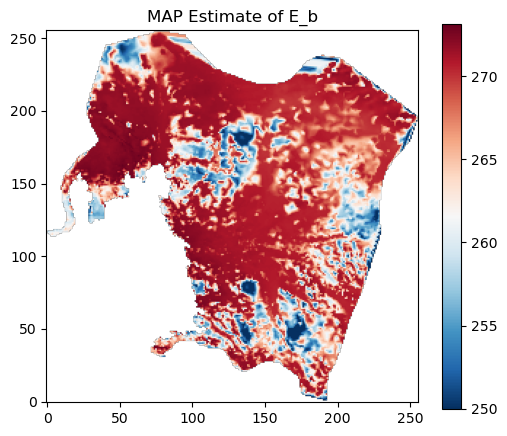

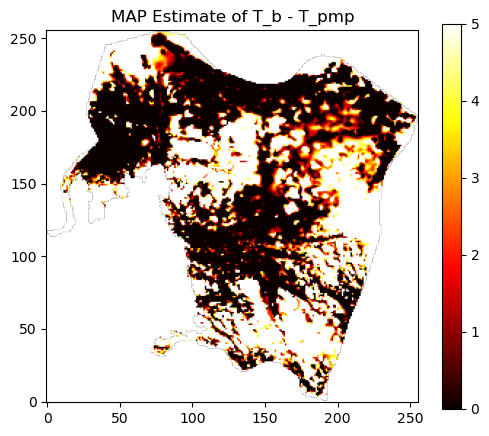

In [21]:
X_optimized = X.detach().numpy()

Eb_MAP = pca_X.inverse_transform(X_optimized.reshape(1, -1)).reshape(256, 256)
Eb_MAP_ori = torch.from_numpy(Eb_MAP * Eb_std_data.reshape(256, 256) + Eb_mean_data.reshape(256, 256))
Tb_MAP = enthalpy_to_temperature(Eb_MAP_ori.flatten(), Tpmp.flatten()).reshape(256, 256).numpy()
# reverse standardize and back to temperature 
plt.figure(figsize=(6, 5))
plt.imshow(Tb_MAP * model_bound_data_ori, cmap='RdBu_r', vmin=250, vmax=273.15)
plt.title('MAP Estimate of E_b')
plt.colorbar()
plt.gca().invert_yaxis()
dT_to_pmp = Tpmp.reshape(256,256) - Tb_MAP
# plot as contour lines
plt.figure(figsize=(6, 5))
plt.imshow(dT_to_pmp * model_bound_data_ori, cmap='hot', vmin=0, vmax=5)
plt.title('MAP Estimate of T_b - T_pmp')
plt.colorbar()
plt.gca().invert_yaxis()
plt.show()

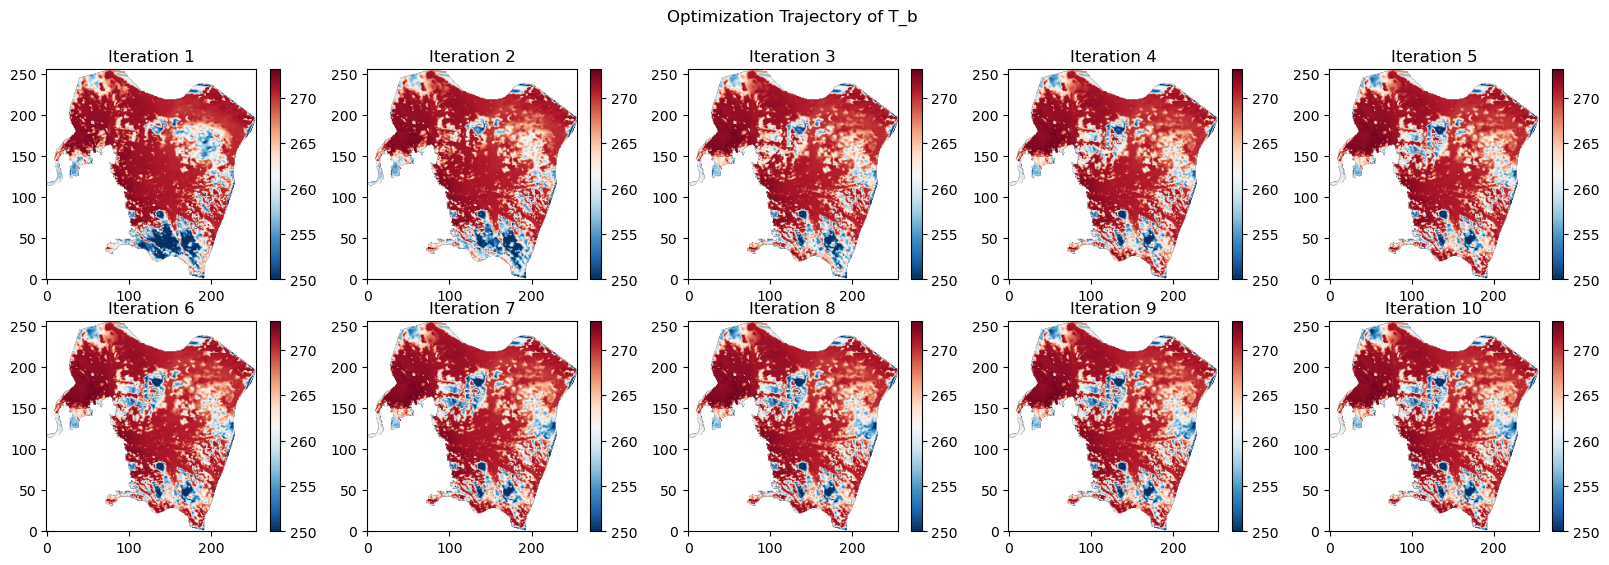

In [22]:
# plot all the snapshots to see the optimization trajectory
n_snapshots = len(saved_snapshots)
plt.figure(figsize=(20, 6))
for i, snapshot in enumerate(saved_snapshots):
    Eb_snapshot = pca_X.inverse_transform(snapshot.reshape(1, -1)).reshape(256, 256)
    Eb_snapshot_ori = torch.from_numpy(Eb_snapshot * Eb_std_data.reshape(256, 256) + Eb_mean_data.reshape(256, 256))
    Tb_snapshot = enthalpy_to_temperature(Eb_snapshot_ori.flatten(), Tpmp.flatten()).reshape(256, 256)
    plt.subplot(2, n_snapshots//2, i+1)
    plt.imshow(Tb_snapshot * model_bound_data_ori, cmap='RdBu_r', vmin=250, vmax=273.15)
    
    plt.title(f'Iteration {i+1}')
    plt.colorbar()
    plt.gca().invert_yaxis()
plt.suptitle('Optimization Trajectory of T_b')
plt.show()

# Latent mode importance sampling

In [ ]:
# create the inference_param dict
# which stores the following fields:
#.    1. thawed_evidence
#     2. frozen_evidence
#     3. Eb_sim_std: standardization std array back to the physical enthalpy space
#     4. Eb_sim_mean: standardization mean array back to the physical enthalpy space
#     5. H_struct: dict with key "H" (ice thickness)

# create the evidence_paths:
#     1. thawed_path: path string for the thawed base mask
#     2. frozen_path: path string for the frozen base mask

inference_param = {
    "thawed_evidence": thawed_mask_data,
    "frozen_evidence": frozen_mask_data,
    "Eb_sim_std": Eb_std_data,
    "Eb_sim_mean": Eb_mean_data,
    "H": H
}




(65536,)

In [27]:
gmm_propagated.sample(5).shape

(5, 25)